Работа с табличными данными

In [58]:
import pandas as pd

In [59]:
df = pd.read_csv('dataset/train.csv', sep="|")
df

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
0,5,1054,54.70,7,0,3,0.027514,0.051898,0.241379,0
1,3,108,27.36,5,2,4,0.129630,0.253333,0.357143,0
2,3,1516,62.16,3,10,5,0.008575,0.041003,0.230769,0
3,6,1791,92.31,8,4,4,0.016192,0.051541,0.275862,0
4,5,430,81.53,3,7,2,0.062791,0.189605,0.111111,0
...,...,...,...,...,...,...,...,...,...,...
1874,1,321,76.03,8,7,2,0.071651,0.236854,0.347826,0
1875,1,397,41.89,5,5,0,0.065491,0.105516,0.192308,1
1876,4,316,41.83,5,8,1,0.094937,0.132373,0.166667,0
1877,2,685,62.68,1,6,2,0.035036,0.091504,0.041667,0


In [60]:
df.dtypes

trustLevel                     int64
totalScanTimeInSeconds         int64
grandTotal                   float64
lineItemVoids                  int64
scansWithoutRegistration       int64
quantityModifications          int64
scannedLineItemsPerSecond    float64
valuePerSecond               float64
lineItemVoidsPerPosition     float64
fraud                          int64
dtype: object

In [61]:
df.isna().sum()

trustLevel                   0
totalScanTimeInSeconds       0
grandTotal                   0
lineItemVoids                0
scansWithoutRegistration     0
quantityModifications        0
scannedLineItemsPerSecond    0
valuePerSecond               0
lineItemVoidsPerPosition     0
fraud                        0
dtype: int64

In [62]:
df.fraud.value_counts()

fraud
0    1775
1     104
Name: count, dtype: int64

In [63]:
y = df["fraud"]
X = df.drop(columns=["fraud"])

In [64]:
df.describe()

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
count,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000,1879.000000
mean,3.401809,932.153273,50.864492,5.469931,4.904204,2.525279,0.058138,0.201746,0.745404,0.055349
std,1.709404,530.144640,28.940202,3.451169,3.139697,1.695472,0.278512,1.242135,1.327241,0.228720
min,1.000000,2.000000,0.010000,0.000000,0.000000,0.000000,0.000548,0.000007,0.000000,0.000000
25%,2.000000,474.500000,25.965000,2.000000,2.000000,1.000000,0.008384,0.027787,0.160000,0.000000
50%,3.000000,932.000000,51.210000,5.000000,5.000000,3.000000,0.016317,0.054498,0.350000,0.000000
75%,5.000000,1397.000000,77.285000,8.000000,8.000000,4.000000,0.032594,0.107313,0.666667,0.000000
max,6.000000,1831.000000,99.960000,11.000000,10.000000,5.000000,6.666667,37.870000,11.000000,1.000000


## Предобработка данных

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [66]:
X_train.shape

(1503, 9)

In [67]:
X_val.shape

(376, 9)

In [68]:
X_test = pd.read_csv("dataset/test.csv", sep="|")
X_test

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition
0,4,467,88.48,4,8,4,0.014989,0.189465,0.571429
1,3,1004,58.99,7,6,1,0.026892,0.058755,0.259259
2,1,162,14.00,4,5,4,0.006173,0.086420,4.000000
3,5,532,84.79,9,3,4,0.026316,0.159380,0.642857
4,5,890,42.16,4,0,0,0.021348,0.047371,0.210526
...,...,...,...,...,...,...,...,...,...
498116,4,783,59.10,2,2,0,0.012771,0.075479,0.200000
498117,1,278,98.90,9,5,4,0.050360,0.355755,0.642857
498118,3,300,5.41,6,6,4,0.030000,0.018033,0.666667
498119,2,1524,33.97,2,5,3,0.005906,0.022290,0.222222


In [69]:
y_test = pd.read_csv("dataset/DMC-2019-realclass.csv", sep="|")["fraud"]
y_test.value_counts()

fraud
0    474394
1     23727
Name: count, dtype: int64

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [71]:
import torch

In [72]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

In [73]:
y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [74]:
from torch.utils.data import TensorDataset, DataLoader

In [75]:
BATCH_SIZE = 64

In [76]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=256)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=1024)

вес для редкого класса, чтобы модель его не пропускала

In [77]:
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()

In [78]:
pos_weight = n_neg / n_pos
pos_weight

tensor(17.1084)

## Модель

In [79]:
from dotenv import load_dotenv
import wandb
import os
import logging
import time

timestamp = str(time.time()).replace('.', '_')
log_file = f'part_2_{timestamp}.log'
logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True
)

load_dotenv()

WANDB_API_KEY = os.getenv("WANDB_API_KEY")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "gp5")
WANDB_ENTITY = os.getenv("WANDB_ENTITY")

logging.info("Ключи для WANDB подгружены")


In [80]:
wandb.login(key=WANDB_API_KEY)
logging.info("Залогинились в wandb")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/evgeniy/.netrc


In [81]:
import torch.nn as nn

In [82]:
EPOCHS = 30
LR = 0.001


model = nn.Sequential(
    nn.Linear(9, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [83]:
config = {
    "model": "MLP",
    "optimizer": str(optimizer.__class__.__name__),
    "task": "fraud_detection",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "pos_weight": pos_weight,
    "loss": str(loss_fn.__class__.__name__),
    "architecture": str(model)
}

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="nn_baseline", config=config)

In [84]:
logging.info("Начали обучение модели")
for epoch in range(1, EPOCHS+1):
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        epoch_loss += loss.item()
        optimizer.step()
    
    epoch_loss /= len(train_loader)

    logging.info(f"эпоха: {epoch}, loss:  {round(epoch_loss, 4)}")
    print("эпоха", epoch, "loss", round(epoch_loss, 4))
    wandb.log({"epoch": epoch, "train/loss": epoch_loss})

эпоха 1 loss 1.2826
эпоха 2 loss 1.2478
эпоха 3 loss 1.175
эпоха 4 loss 1.0695
эпоха 5 loss 0.9469
эпоха 6 loss 0.8113
эпоха 7 loss 0.7046
эпоха 8 loss 0.6106
эпоха 9 loss 0.5436
эпоха 10 loss 0.4945
эпоха 11 loss 0.4587
эпоха 12 loss 0.4291
эпоха 13 loss 0.4038
эпоха 14 loss 0.3944
эпоха 15 loss 0.3795
эпоха 16 loss 0.3578
эпоха 17 loss 0.3457
эпоха 18 loss 0.339
эпоха 19 loss 0.33
эпоха 20 loss 0.3247
эпоха 21 loss 0.308
эпоха 22 loss 0.3009
эпоха 23 loss 0.3023
эпоха 24 loss 0.2949
эпоха 25 loss 0.2834
эпоха 26 loss 0.2761
эпоха 27 loss 0.2726
эпоха 28 loss 0.2608
эпоха 29 loss 0.254
эпоха 30 loss 0.2542


## Проверка

In [85]:
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits)

probs[:5]

tensor([[9.3468e-06],
        [4.5143e-02],
        [9.0047e-10],
        [5.5245e-07],
        [1.6040e-06]])

In [86]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_true = y_test.numpy()
y_prob = probs.numpy()

In [87]:
auc_score = roc_auc_score(y_true, y_prob)
logging.info(f"На тесте ROC_AUC: {auc_score}")
auc_score



0.9708791574031119

In [88]:
from sklearn.metrics import precision_score, recall_score

In [89]:
y_pred = (y_prob > 0.5).astype(int)

In [90]:
pre_score = precision_score(y_true, y_pred)
logging.info(f"На тесте Precision: {pre_score}")
pre_score

0.3383968575461855

In [91]:
rec_score = recall_score(y_true, y_pred)
logging.info(f"На тесте Recall: {rec_score}")
rec_score

0.9294896109916972

## Попробуем подобрать порог

In [92]:
with torch.no_grad():
    val_prob = torch.sigmoid(model(X_val)).numpy()

val_true = y_val.numpy()

In [93]:
from sklearn.metrics import precision_recall_curve

target_recall = 0.90

prec, rec, thr = precision_recall_curve(val_true, val_prob)
best_threshold = thr[rec[:-1] >= target_recall].max()
logging.info(f"Подобрали порог {best_threshold}")
wandb.log({"best_threshold": best_threshold})
best_threshold

0.73698515

In [94]:
y_pred = (y_prob > best_threshold).astype(int)

In [95]:
pre_at_score = precision_score(y_true, y_pred)
logging.info(f"На тесте Precision: {pre_at_score}")
pre_at_score

0.4186700767263427

In [96]:
rec_at_score = recall_score(y_true, y_pred)
logging.info(f"На тесте Recall: {rec_at_score}")
rec_at_score

0.8279175622708307

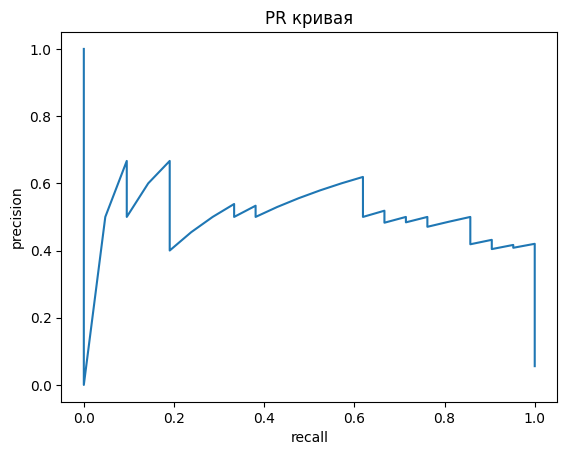

In [97]:
import matplotlib.pyplot as plt

plt.plot(rec, prec)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR кривая")
plt.show()

In [98]:
import pickle

pickle.dump(model.state_dict(), open("models/model_fraud_1.pkl", 'wb'))
logging.info("Сохранили веса модели в папку models")

In [99]:
results = wandb.Table(columns=['model', 'test/roc_auc', 'test/precision', 'test/recall', 'test/recall_new_threshold', 'test/precision_new_threshold'])
results.add_data("nn_baseline", auc_score, pre_score, rec_score, rec_at_score, pre_at_score)
wandb.log({"results": results})

In [100]:
artifact = wandb.Artifact(name="model_fraud_1", type="model", description="Тест логгирования модели MLP")

artifact.add_file("models/model_fraud_1.pkl")
artifact.add_file(log_file)
run.log_artifact(artifact)




<Artifact model_fraud_1>

In [101]:
run.finish()

IOStream.flush timed out


best_threshold,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,██▇▇▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
best_threshold,0.73699
epoch,30
train/loss,0.25419


# ансамбль

In [102]:
import numpy as np

In [103]:
def build_model():
    return nn.Sequential(
        nn.Linear(9, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1),
        )

In [104]:
EPOCHS = 120
LR = 0.001
WEIGHT_DECAY = 1e-4
N_ENSEMBLE = 5

net = build_model()
opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [105]:
loss_fn2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [106]:
config = {
    "model": "Ensemble",
    "optimizer": str(opt.__class__.__name__),
    "task": "fraud_detection",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "pos_weight": pos_weight,
    "loss": str(loss_fn2.__class__.__name__),
    "n_ensemble": N_ENSEMBLE,
    "architecture": str(net)
}

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="ensemble", config=config)

In [ ]:
test_probs = []
logging.info("Запустили обучение моделей ансамбля")

np.random.seed(42)
seeds = np.random.randint(1, 525252, size=N_ENSEMBLE)
ensemble = []
for i in range(N_ENSEMBLE):
    seed = seeds[i]
    torch.manual_seed(seed)
    net = build_model()
    opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    logging.info(f"Запустили обучение модели {i+1}. Сид: {seed}")


    net.train()
    for epoch in range(1, EPOCHS + 1):
        epoch_loss = 0
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn2(net(xb), yb)
            loss.backward()
            epoch_loss += loss.item()
            opt.step()
        
        logging.info(f"эпоха: {epoch}, loss:  {round(epoch_loss, 4)}")
        wandb.log({"epoch": epoch, f"ensemble/{i}/train_loss": epoch_loss})
    
    ensemble.append(net.state_dict())

    net.eval()
    with torch.no_grad():
        test_probs.append(torch.sigmoid(net(X_test)).numpy())

    logging.info(f"Сеть {i} обучена")
    print("сеть", i, "обучена")

probs2 = np.mean(test_probs, axis=0)

сеть 0 обучена
сеть 1 обучена


In [ ]:
auc_score = roc_auc_score(y_true, probs2)
logging.info(f"На тесте ROC_AUC: {auc_score}")
auc_score

0.9826593273986224

In [ ]:
pre_score = average_precision_score(y_true, probs2)
logging.info(f"На тесте Precision: {pre_score}")
pre_score

0.7698055725366236

In [ ]:
results = wandb.Table(columns=['model', 'test/avg_roc_auc', 'test/avg_precision'])
results.add_data("ensemble", auc_score, pre_score)
wandb.log({"results": results})

In [ ]:
import pickle

pickle.dump(ensemble, open("models/model_fraud_ensemble.pkl", 'wb'))
logging.info("Сохранили веса моделей ансамбля в папку models")

In [ ]:
artifact = wandb.Artifact(name="model_fraud_ensemble.pkl", type="model", description="Ансамбль моделей для определения Фрода")

artifact.add_file("models/model_fraud_ensemble.pkl")
artifact.add_file(log_file)
run.log_artifact(artifact)


<Artifact model_fraud_ensemble.pkl>

In [ ]:
run.finish()

epoch,▁▁▂▂▂▃▃▄▄▅▆▇▇▇█▂▂▃▄▄▅▅▅▆▂▄██▂▃▃▃▄▇▇▃▄▄▅█
i_ensemble,▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆█████████
train/loss,▂▂▂▁▁▂▂▂▁▂▁▁▁▅▃▂▂▂▂▁▁█▄▃▂▂▂▂▁▁▁▆▄▂▂▁▁▁▁▁
epoch,120
i_ensemble,4
train/loss,4.35925


In [ ]:
wandb.finish()
